In [ ]:
%pip install -q torch torchvision matplotlib pandas tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import os
import json
import time
import glob
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from tqdm.auto import tqdm

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Setting up config for regenerating results
cfg = {
    "seed": 42,          # reproducibility seed
    "device": "cuda",    # prefer GPU if available

    "week5": {
        "run_dir": "../week5/output/kaggle/working/runs/20260224_074746_week5",  # path to Week5 artifacts (can set manually)
        "zip_path": "../week5/output.zip",  # optional: unzip Week5 artifacts if only zip is available
    },

    "run": {
        "root": "runs",   # where to create new runs
        "tag": "week6",   # run name suffix
    },

    "data": {
        "batch_size": 128,   # dataloader batch size
        "num_workers": 0,    # safer default for Kaggle/Windows
        "subset": None,      # set e.g. 5000 for quick debug
    },

    "probe": {
        "aug": {
            "thin_k": 1,   # erosion strength (thinner strokes)
            "thick_k": 1,  # dilation strength (thicker strokes)
            "blend": 0.2,  # mix original + augmented
        }
    },

    "steer": {
        "direction_batches": 200,  # batches to estimate steering direction
        "alphas": [-4.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 4.0],  # edit strengths along the direction
        "preview_n": 8,            # how many samples to visualize
    }
}


def get_device(name: str) -> torch.device:
    # use CUDA if requested and available, else CPU
    if name == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def set_seed(seed: int) -> None:
    # set seeds for deterministic runs
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int):
    # per-worker seed for DataLoader workers
    worker_seed = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def save_json(path: str, obj: dict) -> None:
    # save dict as JSON (make parent dirs if needed)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def make_run_dir(root: str, tag: str) -> str:
    # create a new run folder with checkpoints/plots subdirs
    ts = time.strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(root, f"{ts}_{tag}")
    os.makedirs(os.path.join(run_dir, "checkpoints"), exist_ok=False)
    os.makedirs(os.path.join(run_dir, "plots"), exist_ok=True)
    return run_dir


def maybe_unpack_week5(zip_path: str) -> None:
    # unzip Week5 artifacts if zip exists
    if zip_path and os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(".")


def find_week5_run(manual_path=None) -> str:
    # get Week5 run dir: manual path first, otherwise auto-detect latest *_week5
    if manual_path is not None:
        if os.path.isdir(manual_path):
            return manual_path
        raise FileNotFoundError(f"Manual week5 run dir not found: {manual_path}")

    candidates = []
    for pat in ["runs/*_week5", "kaggle/working/runs/*_week5", "/kaggle/working/runs/*_week5"]:
        candidates.extend(glob.glob(pat))

    candidates = sorted(set(candidates))
    if not candidates:
        raise FileNotFoundError(
            "Week 5 run dir not found. Put artifacts into runs/*_week5 "
            "or set cfg['week5']['run_dir'] manually."
        )
    return candidates[-1]


def detect_data_root() -> str:
    # pick a data root depending on environment
    for p in ["data", "kaggle/working/data", "/kaggle/working/data"]:
        if os.path.exists(p):
            return p
    return "data"


set_seed(int(cfg["seed"]))               # reproducible run
device = get_device(cfg["device"])       # resolve device

maybe_unpack_week5(cfg["week5"]["zip_path"])  # unzip Week5 artifacts if needed

week5_run_dir = find_week5_run(cfg["week5"]["run_dir"])  # locate Week5 run dir
print("week5_run_dir:", week5_run_dir)

# load Week5 config for provenance
week5_cfg_path = os.path.join(week5_run_dir, "config.json")
with open(week5_cfg_path, "r", encoding="utf-8") as f:
    week5_cfg = json.load(f)

# create Week6 run dir + save combined config snapshot
run_dir = make_run_dir(cfg["run"]["root"], cfg["run"]["tag"])
save_json(
    os.path.join(run_dir, "config.json"),
    {"week6_cfg": cfg, "week5_run_dir": week5_run_dir, "week5_cfg": week5_cfg}
)

print("week6_run_dir:", run_dir)         # where outputs go
print("device:", device)                 # resolved device

week5_run_dir: ../week5/output/kaggle/working/runs/20260224_074746_week5
week6_run_dir: runs\20260228_180215_week6
device: cpu


In [ ]:
def get_mnist_loaders(batch_size: int, num_workers: int, subset=None):
    data_root = detect_data_root()          # pick data path (local vs Kaggle)
    tfm = transforms.ToTensor()             # MNIST -> tensor in [0,1]

    # download/load MNIST splits
    train_ds = datasets.MNIST(root=data_root, train=True,  download=True, transform=tfm)
    test_ds = datasets.MNIST(root=data_root, train=False, download=True, transform=tfm)

    # optional: use only first N train samples for quick experiments
    if subset is not None:
        train_ds = Subset(train_ds, list(range(int(subset))))

    # DataLoader RNG: makes shuffling deterministic across runs
    g = torch.Generator()
    g.manual_seed(int(cfg["seed"]))

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,                 # shuffle for training
        num_workers=num_workers,
        pin_memory=True,              # faster host->GPU transfer (if using CUDA)
        worker_init_fn=seed_worker,   # seed each worker deterministically
        generator=g,                  # deterministic shuffle order
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,                # no need to shuffle test
        num_workers=num_workers,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
    )

    return train_loader, test_loader


# take dataloader params from Week5 config if present, otherwise fall back to current cfg
batch_size = int(week5_cfg.get("data", {}).get("batch_size",  cfg["data"]["batch_size"]))
num_workers = int(week5_cfg.get("data", {}).get("num_workers", cfg["data"]["num_workers"]))
subset = week5_cfg.get("data", {}).get("subset",         cfg["data"]["subset"])

train_loader, test_loader = get_mnist_loaders(batch_size, num_workers, subset)
print("batch_size:", batch_size)            # quick sanity check in logs

batch_size: 128


In [ ]:
# the models arcitectures from the previous week
class ConvEncoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),   # 28 -> 14
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),  # 14 -> 7
            nn.ReLU(inplace=True),
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_lv = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        h = self.net(x).flatten(1)
        mu = self.fc_mu(h)
        lv = self.fc_lv(h)
        return mu, lv


class ConvDecoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 7 -> 14
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),   # 14 -> 28
        )

    def forward(self, z):
        h = self.fc(z).view(z.size(0), 64, 7, 7)
        return self.net(h)  # logits


class ConvVAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.enc = ConvEncoder(latent_dim)
        self.dec = ConvDecoder(latent_dim)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, lv = self.enc(x)
        z = self.reparam(mu, lv)
        x_logits = self.dec(z)
        return x_logits, mu, lv


class DigitCNN(nn.Module):
    def __init__(self, feat_dim: int = 128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28 -> 14
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14 -> 7
        )
        self.fc1 = nn.Linear(64 * 7 * 7, feat_dim)
        self.fc2 = nn.Linear(feat_dim, 10)

    def forward(self, x, return_feat: bool = False):
        h = self.conv(x).flatten(1)
        feat = F.relu(self.fc1(h))
        logits = self.fc2(feat)
        return (logits, feat) if return_feat else logits


class ThicknessProbe(nn.Module):
    def __init__(self, in_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2),  # 0=thin, 1=thick
        )

    def forward(self, feat):
        return self.net(feat)

In [ ]:
latent_dim = int(week5_cfg.get("vae", {}).get("latent_dim", 16))  # reuse latent dim from Week5 (fallback=16)

ckpt_dir = os.path.join(week5_run_dir, "checkpoints")            # where Week5 checkpoints live
vae_candidates = sorted(glob.glob(os.path.join(ckpt_dir, "vae_epoch*.pt")))  # all saved VAE epochs
if not vae_candidates:
    raise FileNotFoundError(f"No VAE checkpoints found in: {ckpt_dir}")

vae_path = vae_candidates[-1]                                    # take latest VAE checkpoint by filename sorting
clf_path = os.path.join(ckpt_dir, "clf_best.pt")                 # best digit classifier checkpoint
probe_path = os.path.join(ckpt_dir, "probe_best.pt")             # best thickness probe checkpoint

# fail fast if required artifacts are missing
if not os.path.exists(clf_path):
    raise FileNotFoundError(f"Missing classifier checkpoint: {clf_path}")
if not os.path.exists(probe_path):
    raise FileNotFoundError(f"Missing probe checkpoint: {probe_path}")

# recreate model architectures (must match how they were saved in Week5)
vae = ConvVAE(latent_dim=latent_dim).to(device)
clf = DigitCNN(feat_dim=128).to(device)
probe = ThicknessProbe(in_dim=128).to(device)

# load checkpoint dicts (map to current device to avoid CPU/GPU mismatch)
vae_ckpt = torch.load(vae_path, map_location=device)
clf_ckpt = torch.load(clf_path, map_location=device)
probe_ckpt = torch.load(probe_path, map_location=device)

# restore weights (expecting {"model": state_dict} format)
vae.load_state_dict(vae_ckpt["model"])
clf.load_state_dict(clf_ckpt["model"])
probe.load_state_dict(probe_ckpt["model"])

# inference mode (no dropout/bn updates)
vae.eval()
clf.eval()
probe.eval()

# log what exactly got loaded for reproducibility/debugging
print("Loaded:")
print("VAE :", vae_path)
print("CLF :", clf_path)
print("PROBE :", probe_path)

Loaded:
  VAE  : ../week5/output/kaggle/working/runs/20260224_074746_week5\checkpoints\vae_epoch020.pt
  CLF  : ../week5/output/kaggle/working/runs/20260224_074746_week5\checkpoints\clf_best.pt
  PROBE: ../week5/output/kaggle/working/runs/20260224_074746_week5\checkpoints\probe_best.pt


In [ ]:
# reuse augmentation hyperparams from Week5 if present, otherwise take current cfg defaults
thin_k = int(week5_cfg.get("probe", {}).get("aug", {}).get("thin_k",  cfg["probe"]["aug"]["thin_k"]))
thick_k = int(week5_cfg.get("probe", {}).get("aug", {}).get("thick_k", cfg["probe"]["aug"]["thick_k"]))
blend = float(week5_cfg.get("probe", {}).get("aug", {}).get("blend", cfg["probe"]["aug"]["blend"]))


def gray_dilate(x: torch.Tensor, iters: int = 1, k: int = 3) -> torch.Tensor:
    # grayscale dilation via max-pooling (repeat iters times)
    out = x
    pad = k // 2
    for _ in range(iters):
        out = F.max_pool2d(out, kernel_size=k, stride=1, padding=pad)
    return out


def gray_erode(x: torch.Tensor, iters: int = 1, k: int = 3) -> torch.Tensor:
    # grayscale erosion via "negative max-pooling" trick: erode(x) = -dilate(-x)
    out = x
    pad = k // 2
    for _ in range(iters):
        out = -F.max_pool2d(-out, kernel_size=k, stride=1, padding=pad)
    return out


@torch.no_grad()
def thickness_transform(x: torch.Tensor, mode: str, iters: int, blend: float = 0.2) -> torch.Tensor:
    # apply a thickness edit to an image batch: "thick" -> dilate, "thin" -> erode
    if mode == "thick":
        out = gray_dilate(x, iters=iters, k=3)
    elif mode == "thin":
        out = gray_erode(x, iters=iters, k=3)
    else:
        raise ValueError("mode must be 'thin' or 'thick'")

    # renormalize per-image to keep intensities comparable + blend with original for stability
    eps = 1e-6
    out = out / (out.amax(dim=(1, 2, 3), keepdim=True) + eps)
    out = (1.0 - blend) * out + blend * x
    return out.clamp(0.0, 1.0)  # keep valid pixel range


@torch.no_grad()
def encode_mu(vae: nn.Module, x: torch.Tensor) -> torch.Tensor:
    # encode images to latent mean (mu) only
    mu, _ = vae.enc(x)
    return mu


@torch.no_grad()
def decode_sigmoid(vae: nn.Module, z: torch.Tensor) -> torch.Tensor:
    # decode latents and squash to [0,1] image space
    return torch.sigmoid(vae.dec(z))


@torch.no_grad()
def digit_acc_on_imgs(clf: nn.Module, x: torch.Tensor, y: torch.Tensor) -> float:
    # classifier accuracy on a batch of images
    pred = clf(x).argmax(dim=1)
    return (pred == y).float().mean().item()


@torch.no_grad()
def probe_scores_on_imgs(clf: nn.Module, probe: nn.Module, x: torch.Tensor):
    # run clf to get features, then probe to get "thickness" signal
    _, feat = clf(x, return_feat=True)
    logits = probe(feat)

    # simple summary stats: mean margin (thick - thin) and mean P(thick)
    margin = (logits[:, 1] - logits[:, 0]).mean().item()
    p_thick = torch.softmax(logits, dim=1)[:, 1].mean().item()
    return margin, p_thick


@torch.no_grad()
def mean_ink(x: torch.Tensor) -> torch.Tensor:
    # heuristic: average pixel intensity per image (proxy for "ink amount")
    return x.mean(dim=(1, 2, 3))

In [ ]:
@torch.no_grad()
def learn_global_thickness_direction(
    vae: nn.Module,
    loader: DataLoader,
    thin_k: int,
    thick_k: int,
    blend: float,
    max_batches: int = 200,
):
    deltas = []  # store (z_thick - z_thin) for many image pairs

    for bi, (x, _) in enumerate(loader):
        # limit compute: only use first max_batches batches
        if max_batches is not None and bi >= max_batches:
            break

        x = x.to(device)  # move batch to GPU/CPU

        # create paired augmentations from the same images
        x_thin = thickness_transform(x, mode="thin",  iters=thin_k,  blend=blend)
        x_thick = thickness_transform(x, mode="thick", iters=thick_k, blend=blend)

        # encode to latent means (mu) so it's stable (no sampling noise)
        z_thin = encode_mu(vae, x_thin)
        z_thick = encode_mu(vae, x_thick)

        # delta points in the "thickness increases" direction for this batch
        deltas.append(z_thick - z_thin)

    D = torch.cat(deltas, dim=0)        # [N, latent_dim] all deltas stacked
    d = D.mean(dim=0)                   # global direction = average delta
    d = d / (d.norm() + 1e-8)           # normalize for a clean step-size interpretation

    # some quick diagnostics for logging
    stats = {
        "num_pairs": int(D.size(0)),                          # total number of deltas
        "latent_dim": int(D.size(1)),                         # latent dimension
        "mean_delta_norm_before_norm": float(D.mean(dim=0).norm().item()),  # ||mean delta||
        "direction_norm_after_norm": float(d.norm().item()),  # should be ~1.0
    }
    return d, stats


# learn the steering direction on training data (using cfg for batch budget)
direction, direction_stats = learn_global_thickness_direction(
    vae=vae,
    loader=train_loader,
    thin_k=thin_k,
    thick_k=thick_k,
    blend=blend,
    max_batches=int(cfg["steer"]["direction_batches"]),
)

print(direction_stats)  # print stats for sanity checking

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'num_pairs': 25600, 'latent_dim': 16, 'mean_delta_norm_before_norm': 4.9720330238342285, 'direction_norm_after_norm': 1.0}


In [ ]:
@torch.no_grad()
def eval_week6_protocol(
    vae: nn.Module,
    clf: nn.Module,
    probe: nn.Module,
    loader: DataLoader,
    direction: torch.Tensor,
    alphas,
    thin_k: int,
    thick_k: int,
    blend: float,
    max_batches=None,
):
    def new_bucket():
        # accumulators for one condition (we store sums and divide by n later)
        return {
            "n": 0,
            "digit_acc_sum": 0.0,
            "probe_margin_sum": 0.0,
            "probe_p_thick_sum": 0.0,
        }

    buckets = {}  # cond_name -> accumulator dict

    def update(name: str, x_img: torch.Tensor, y_true: torch.Tensor):
        # compute metrics on a batch and add them to the condition bucket
        B = x_img.size(0)
        da = digit_acc_on_imgs(clf, x_img, y_true)
        pm, pt = probe_scores_on_imgs(clf, probe, x_img)

        if name not in buckets:
            buckets[name] = new_bucket()

        buckets[name]["n"] += B
        buckets[name]["digit_acc_sum"] += da * B
        buckets[name]["probe_margin_sum"] += pm * B
        buckets[name]["probe_p_thick_sum"] += pt * B

    ink_gap_sum = 0.0  # quick sanity check that thick>thin actually changes "ink"
    ink_n = 0

    for bi, (x, y) in enumerate(loader):
        # optional compute cap
        if max_batches is not None and bi >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        # 1) baseline: original images
        update("orig", x, y)

        # 2) deterministic augmentations: thin / thick
        x_thin  = thickness_transform(x, mode="thin",  iters=thin_k,  blend=blend)
        x_thick = thickness_transform(x, mode="thick", iters=thick_k, blend=blend)

        update("aug_thin",  x_thin,  y)
        update("aug_thick", x_thick, y)

        # sanity metric: average ink difference between thick and thin
        ink_gap_sum += (mean_ink(x_thick) - mean_ink(x_thin)).sum().item()
        ink_n += x.size(0)

        # 3) reconstructions of original inputs (encode mu -> decode)
        z = encode_mu(vae, x)
        x_rec = decode_sigmoid(vae, z)
        update("recon_orig", x_rec, y)

        # 4) reconstructions of augmented inputs
        z_thin  = encode_mu(vae, x_thin)
        z_thick = encode_mu(vae, x_thick)
        x_rec_thin  = decode_sigmoid(vae, z_thin)
        x_rec_thick = decode_sigmoid(vae, z_thick)

        update("recon_aug_thin",  x_rec_thin,  y)
        update("recon_aug_thick", x_rec_thick, y)

        # 5) steered edits: move original z along the learned direction
        for a in alphas:
            z_s = z + float(a) * direction.unsqueeze(0)  # broadcast direction to batch
            x_s = decode_sigmoid(vae, z_s)
            update(f"steer_a={a}", x_s, y)

    # convert buckets -> dataframe with averaged metrics
    rows = []
    for name, v in buckets.items():
        n = max(1, v["n"])
        rows.append(
            {
                "cond": name,
                "digit_acc": v["digit_acc_sum"] / n,
                "probe_margin": v["probe_margin_sum"] / n,
                "probe_p_thick": v["probe_p_thick_sum"] / n,
            }
        )

    df = pd.DataFrame(rows).sort_values("cond").reset_index(drop=True)

    # baselines for "delta" columns
    orig_acc = float(df.loc[df["cond"] == "orig", "digit_acc"].iloc[0])
    recon_margin = float(df.loc[df["cond"] == "recon_orig", "probe_margin"].iloc[0])

    # helpful derived metrics
    df["digit_acc_drop_vs_orig"] = orig_acc - df["digit_acc"]             # content preservation proxy
    df["probe_margin_gain_vs_recon"] = df["probe_margin"] - recon_margin  # thickness change vs recon baseline

    summary = {
        "ink_gap_mean": ink_gap_sum / max(1, ink_n),      # should be > 0 if thick has more ink than thin
        "orig_digit_acc": orig_acc,                       # baseline digit accuracy
        "recon_orig_probe_margin": recon_margin,          # baseline probe signal on recon
    }

    return df, summary

In [ ]:
alphas = list(cfg["steer"]["alphas"])  # steering strengths to sweep

# run the Week6 evaluation protocol on the test set
df_eval, eval_summary = eval_week6_protocol(
    vae=vae,
    clf=clf,
    probe=probe,
    loader=test_loader,
    direction=direction,
    alphas=alphas,
    thin_k=thin_k,
    thick_k=thick_k,
    blend=blend,
    max_batches=None,  # can set e.g. 20 for a quick smoke test
)

# merge all key stats + provenance (paths/checkpoints) into one summary dict
full_summary = {
    **direction_stats,
    **eval_summary,
    "week5_run_dir": week5_run_dir,
    "vae_checkpoint": vae_path,
    "clf_checkpoint": clf_path,
    "probe_checkpoint": probe_path,
}

# persist outputs for the weekly package
csv_path = os.path.join(run_dir, "results_week6.csv")
json_path = os.path.join(run_dir, "summary_week6.json")

df_eval.to_csv(csv_path, index=False)     # main results table
save_json(json_path, full_summary)        # run metadata + summary metrics

print("Saved:", csv_path)
print("Saved:", json_path)

df_eval  # display dataframe in notebook

Saved: runs\20260228_180215_week6\results_week6.csv
Saved: runs\20260228_180215_week6\summary_week6.json


,cond,digit_acc,probe_margin,probe_p_thick,digit_acc_drop_vs_orig,probe_margin_gain_vs_recon
0,aug_thick,0.9740,9.097773,0.988198,0.0169,9.504969
1,aug_thin,0.8127,-7.526398,0.008734,0.1782,-7.119201
2,orig,0.9909,-0.681495,0.421840,0.0000,-0.274298
3,recon_aug_thick,0.8866,7.944444,0.983292,0.1043,8.351641
4,recon_aug_thin,0.8582,-5.578482,0.023437,0.1327,-5.171285
5,recon_orig,0.9722,-0.407197,0.443925,0.0187,0.000000
6,steer_a=-0.5,0.9711,-1.647323,0.320035,0.0198,-1.240127
7,steer_a=-1.0,0.9678,-2.808154,0.213469,0.0231,-2.400957
8,steer_a=-2.0,0.9522,-4.810619,0.072807,0.0387,-4.403422
9,steer_a=-4.0,0.8063,-7.213321,0.004761,0.1846,-6.806124


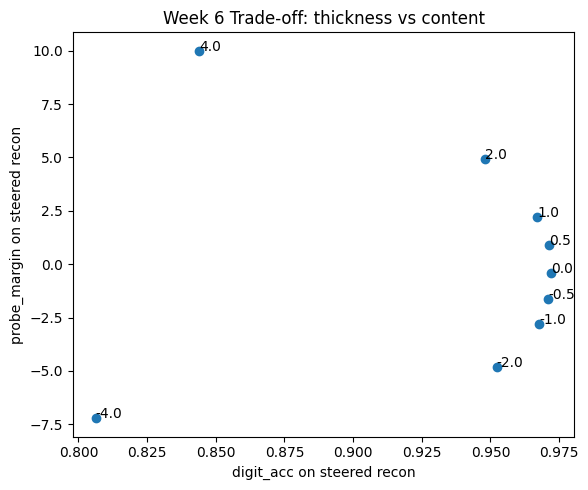

Saved: runs\20260228_180215_week6\plots\tradeoff_probe_vs_digit_acc.png


In [ ]:
# keep only the steered conditions (cond like "steer_a=...")
df_steer = df_eval[df_eval["cond"].str.startswith("steer_a=")].copy()

# scatter: content preservation (digit_acc) vs thickness change (probe_margin)
plt.figure(figsize=(6, 5))
plt.scatter(df_steer["digit_acc"], df_steer["probe_margin"])

# annotate each point with its alpha value for readability
for _, row in df_steer.iterrows():
    a = row["cond"].split("=")[1]  # extract alpha from "steer_a=<alpha>"
    plt.annotate(a, (row["digit_acc"], row["probe_margin"]))

plt.xlabel("digit_acc on steered recon")          # higher = better content preservation
plt.ylabel("probe_margin on steered recon")       # higher = "thicker" according to probe
plt.title("Week 6 Trade-off: thickness vs content")
plt.tight_layout()

# save plot into the run folder
plot_path = os.path.join(run_dir, "plots", "tradeoff_probe_vs_digit_acc.png")
plt.savefig(plot_path, dpi=150)
plt.show()

print("Saved:", plot_path)

In [ ]:
@torch.no_grad()
def save_steering_preview(
    vae: nn.Module,
    loader: DataLoader,
    direction: torch.Tensor,
    alphas,
    out_png: str,
    n: int = 8,
):
    # take one batch and keep only first n samples
    x, y = next(iter(loader))
    x = x[:n].to(device)
    y = y[:n]  # labels not used here, but kept for debugging if needed

    # encode original images to latent means
    z = encode_mu(vae, x)

    # first row: originals; next rows: steered reconstructions for each alpha
    rows_imgs = [x.cpu()]
    for a in alphas:
        z_s = z + float(a) * direction.unsqueeze(0)  # move along direction
        x_s = decode_sigmoid(vae, z_s)               # decode back to image space
        rows_imgs.append(x_s.cpu())

    # stack all rows into one tensor for easy indexing in a grid plot
    grid = torch.cat(rows_imgs, dim=0).squeeze(1)    # [(rows*n), 28, 28]
    rows = len(rows_imgs)                            # 1 + len(alphas)
    cols = n

    # plot as a (rows x cols) image grid
    plt.figure(figsize=(cols, rows))
    idx = 0
    for r in range(rows):
        for c in range(cols):
            plt.subplot(rows, cols, idx + 1)
            plt.imshow(grid[idx], cmap="gray")
            plt.axis("off")
            idx += 1

    plt.tight_layout()
    plt.savefig(out_png, dpi=150)  # save preview to disk
    plt.close()


preview_alphas = [-2.0, 0.0, 2.0]  # a small sweep for qualitative sanity check
preview_path = os.path.join(run_dir, "plots", "steering_preview.png")

save_steering_preview(
    vae=vae,
    loader=test_loader,
    direction=direction,
    alphas=preview_alphas,
    out_png=preview_path,
    n=int(cfg["steer"]["preview_n"]),
)

print("Saved:", preview_path)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Saved: runs\20260228_180215_week6\plots\steering_preview.png


In [16]:
print("=== WEEK 6 SUMMARY ===")
print(f"Week 5 run: {week5_run_dir}")
print(f"Week 6 run: {run_dir}")
print(f"ink_gap_mean: {full_summary['ink_gap_mean']:.6f}")
print(f"orig_digit_acc: {full_summary['orig_digit_acc']:.4f}")
print(f"recon_orig_probe_margin: {full_summary['recon_orig_probe_margin']:.4f}")
print(f"direction_norm_after_norm: {full_summary['direction_norm_after_norm']:.4f}")

print("\nSteering rows:")
display(df_eval[df_eval['cond'].str.startswith('steer_a=')].copy())

=== WEEK 6 SUMMARY ===
Week 5 run: ../week5/output/kaggle/working/runs/20260224_074746_week5
Week 6 run: runs\20260228_180215_week6
ink_gap_mean: 0.186807
orig_digit_acc: 0.9909
recon_orig_probe_margin: -0.4072
direction_norm_after_norm: 1.0000

Steering rows:


,cond,digit_acc,probe_margin,probe_p_thick,digit_acc_drop_vs_orig,probe_margin_gain_vs_recon
6,steer_a=-0.5,0.9711,-1.647323,0.320035,0.0198,-1.240127
7,steer_a=-1.0,0.9678,-2.808154,0.213469,0.0231,-2.400957
8,steer_a=-2.0,0.9522,-4.810619,0.072807,0.0387,-4.403422
9,steer_a=-4.0,0.8063,-7.213321,0.004761,0.1846,-6.806124
10,steer_a=0.0,0.9722,-0.407197,0.443925,0.0187,0.000000
11,steer_a=0.5,0.9712,0.888652,0.573052,0.0197,1.295849
12,steer_a=1.0,0.9671,2.220910,0.695823,0.0238,2.628107
13,steer_a=2.0,0.9479,4.924543,0.880024,0.0430,5.331739
14,steer_a=4.0,0.8439,9.997819,0.990877,0.1470,10.405015
